Goals:
1. create a Pivot Table consist of job title and salary year avg based on each job country
2. create a bar chart that shows a median year salary of top 6 country of data engineering, data scientist and data analyst

In [2]:
# import library
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

1. index: itu buat kolom yang dipakai di row pivotnya
2. columns: kolom yang dipkaia buat kolom
3. aggfunc: aggregat apa yang mau di pakai? size/median/max/min dsb
4. values: value yang diisi buat pivotnya

In [15]:
# create pivot

df.pivot_table(values='salary_year_avg', index='job_country', aggfunc='median', columns='job_title_short')

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_country,,,,,,,,,,
Albania,NaN,NaN,49950.00,NaN,69981.25,NaN,NaN,NaN,157500.0,NaN
Algeria,NaN,NaN,44100.00,45000.0,NaN,NaN,NaN,NaN,NaN,NaN
Argentina,71100.0,197500.0,92771.75,96773.0,71000.00,101029.0,NaN,147500.0,NaN,174500.0
Armenia,NaN,NaN,100500.00,48750.0,NaN,87021.0,NaN,NaN,NaN,NaN
Australia,70000.0,110000.0,109500.00,106712.5,139216.00,101029.0,50640.0,147500.0,157500.0,118350.0
...,...,...,...,...,...,...,...,...,...,...
Uruguay,NaN,NaN,100500.00,NaN,NaN,50000.0,NaN,NaN,57500.0,NaN
Uzbekistan,NaN,NaN,NaN,NaN,30750.00,NaN,NaN,NaN,NaN,NaN
Vietnam,79200.0,NaN,75550.00,96773.0,70000.00,57600.0,105837.5,147500.0,79200.0,53600.0


In [ ]:
# search top 6 countries
top_countries = df['job_country'].value_counts().head(6).index
print(top_countries)

# create pivot and copy it into new variable
df_job_country_salaries = df.pivot_table(
    values='salary_year_avg',
    index='job_country',
    columns='job_title_short',
    aggfunc='median'
).copy()

# assign df dengan 6 country index 
df_job_country_salaries = df_job_country_salaries.loc[top_countries]

# ngefilter kolom df sesuai dengan 3 job
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']
df_job_country_salaries = df_job_country_salaries[job_titles]

df_job_country_salaries

Index(['United States', 'India', 'United Kingdom', 'France', 'Germany',
       'Spain'],
      dtype='object', name='job_country')


job_title_short,Data Analyst,Data Engineer,Data Scientist
job_country,,,
United States,90000.0,125000.0,130000.0
India,100500.0,147500.0,114008.0
United Kingdom,87750.0,110000.0,105300.0
France,69175.0,98301.5,88128.0
Germany,103750.0,147500.0,131560.0
Spain,91977.0,133000.0,88128.0


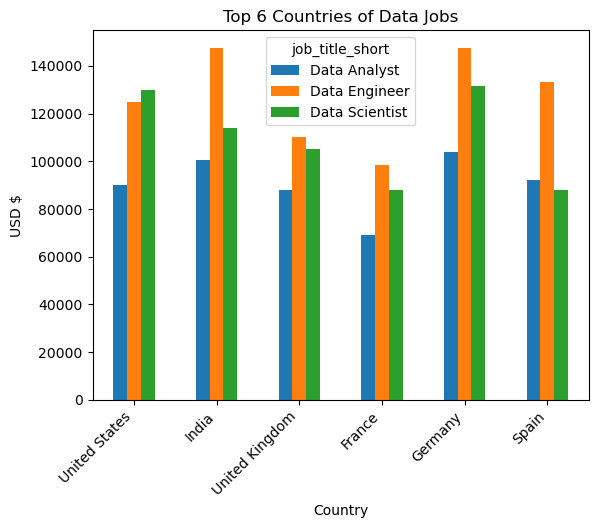

In [35]:
# create bar chart

df_job_country_salaries.plot(kind='bar')
plt.title('Top 6 Countries of Data Jobs')
plt.xlabel('Country')
plt.ylabel('USD $')
plt.xticks(rotation=45, ha='right')
plt.show()